# Sprint 3: IA & ML para retenção de clientes

## Challenge 2: VIN Share e retenção

A FaroAI quer identificar o perfil de relacionamento de cada cliente para orientar a próxima ação da concessionária. Este notebook continua o trabalho da sprint anterior com quatro classes: fiel, abandono, esquecido e econômico.

O experimento usa a base sintética já presente no repositório. O rótulo é criado pelo gerador junto com os dados. As métricas mostram se os modelos recuperam esses rótulos sintéticos. Elas não medem o comportamento real de clientes Ford nem estimam impacto comercial.

A Base 1 contém comportamento pós-compra e serve à segmentação exploratória. A Base 2 contém atributos disponíveis na compra e serve à classificação. O classificador não recebe dados pós-compra.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPOSITORY_URL = "https://github.com/P0lid0/ford-fiap-challenge.git"

def find_repository_root(start: Path) -> Path | None:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "services/ml/src/synthetic.py").is_file():
            return candidate
    return None

REPO_ROOT = find_repository_root(Path.cwd())

if REPO_ROOT is None:
    candidate = Path("/content/ford-fiap-challenge")
    if not candidate.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORY_URL, str(candidate)],
            check=True,
        )
    REPO_ROOT = find_repository_root(candidate)

if REPO_ROOT is None:
    raise RuntimeError("Clone o repositório ou abra o notebook dentro do checkout.")

ML_DIR = REPO_ROOT / "services" / "ml"
sys.path.insert(0, str(ML_DIR))

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "IPython": "ipython",
}
missing_packages = [
    package
    for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing_packages],
        check=True,
    )

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Repositório: {REPO_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print("A célula seguinte detecta suporte CUDA e escolhe o dispositivo do XGBoost.")

Repositório: /home/tept/Projects/ford-fiap-challenge
Python: 3.14.7
A célula seguinte detecta suporte CUDA e escolhe o dispositivo do XGBoost.


In [2]:
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from IPython import get_ipython
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

from src import classifier, clustering, synthetic

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")
get_ipython().run_line_magic("matplotlib", "inline")
SEED = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
EXPERIMENT_STARTED = time.perf_counter()

GPU_QUERY = None
GPU_NAME = None
if xgboost.build_info().get("USE_CUDA"):
    try:
        GPU_QUERY = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            capture_output=True,
            text=True,
            check=False,
        )
    except FileNotFoundError:
        pass
    if GPU_QUERY and GPU_QUERY.returncode == 0:
        detected_gpus = GPU_QUERY.stdout.strip().splitlines()
        if detected_gpus:
            GPU_NAME = detected_gpus[0]
XGBOOST_DEVICE = "cuda" if GPU_NAME else "cpu"

print(f"NumPy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | XGBoost {xgboost.__version__}")
print(f"Execução Colab: {IN_COLAB}")
print(f"XGBoost device: {XGBOOST_DEVICE} | GPU: {GPU_NAME or 'não detectada; usando CPU'}")

NumPy 2.5.3 | pandas 3.0.6 | scikit-learn 1.9.1 | XGBoost 3.4.1
Execução Colab: False
XGBoost device: cuda | GPU: NVIDIA GeForce GTX 1660 Ti


## 1. Problema e dados

O problema de ML é uma classificação supervisionada multiclasse. A entrada contém informações disponíveis no momento da compra. A saída é um dos quatro perfis de retenção.

No experimento da sprint anterior, o gerador atribui o perfil e, em seguida, cria os dados de compra e de pós-compra com distribuições associadas a esse perfil. Por isso, o resultado é uma prova de fluxo e uma comparação de algoritmos. Não é uma validação independente de churn real.

In [3]:
df = synthetic.generate(n=10_000, seed=SEED)
base1, base2 = synthetic.split_base1_base2(df)

TARGET = "perfil_real"
CLASS_NAMES = classifier.PERFIS
MODEL_FEATURES = classifier.NUMERIC + classifier.CATEGORICAL + classifier.BOOLEAN
CLASS_TO_ID = {name: index for index, name in enumerate(CLASS_NAMES)}

print(f"Base completa: {df.shape[0]:,} linhas, {df.shape[1]} colunas")
print(f"Base 1: {base1.shape[0]:,} clientes, {base1.shape[1]} colunas")
print(f"Base 2: {base2.shape[0]:,} clientes, {base2.shape[1]} colunas")
print("Classes:", CLASS_NAMES)

class_distribution = (
    base2[TARGET].value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
    .rename_axis("perfil")
    .reset_index(name="clientes")
)
class_distribution["proporcao"] = class_distribution["clientes"] / len(base2)
display(class_distribution)

excluded_columns = sorted(set(base2.columns) - set(MODEL_FEATURES) - {TARGET})
print(f"Colunas não usadas no classificador: {excluded_columns}")
print("dealership_id fica fora para evitar que o modelo memorize o identificador da concessionária.")

Base completa: 10,000 linhas, 25 colunas
Base 1: 10,000 clientes, 25 colunas
Base 2: 10,000 clientes, 16 colunas
Classes: ['abandono', 'economico', 'esquecido', 'fiel']


,perfil,clientes,proporcao
0,abandono,2765,0.2765
1,economico,1886,0.1886
2,esquecido,2116,0.2116
3,fiel,3233,0.3233


Colunas não usadas no classificador: ['dealership_id']
dealership_id fica fora para evitar que o modelo memorize o identificador da concessionária.


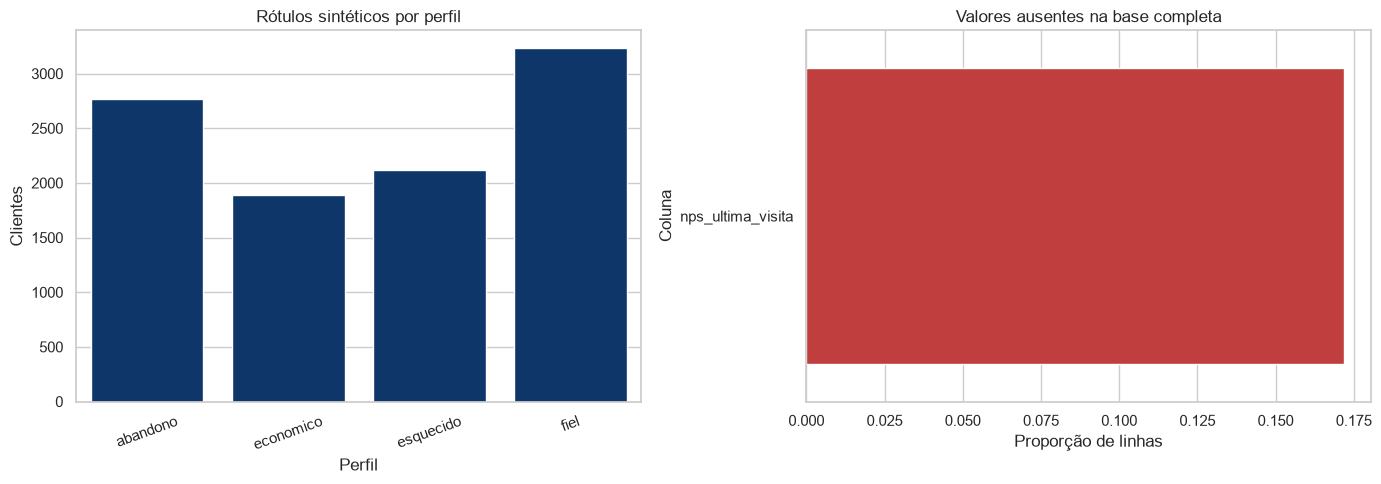

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idade,10000.0,NaN,NaN,NaN,41.4296,11.603254,20.0,33.0,41.0,49.0,84.0
renda_mensal_brl,10000.0,NaN,NaN,NaN,9777.7417,4898.881609,1500.0,6192.0,8888.0,12626.5,30726.0
score_credito,10000.0,NaN,NaN,NaN,690.3679,116.009163,200.0,611.0,695.0,773.0,1000.0
preco_pago_brl,10000.0,NaN,NaN,NaN,94205.9582,27282.431324,35000.0,74933.25,94243.5,112691.25,212685.0
parcelas,10000.0,NaN,NaN,NaN,41.7384,22.735753,0.0,24.0,48.0,60.0,72.0
genero,10000,3,M,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
regiao,10000,5,sudeste,4553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado_civil,10000,4,casado,5121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modelo_comprado,10000,6,Ranger,3280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
versao_comprada,10000,10,Titanium,2658,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=base2, x=TARGET, order=CLASS_NAMES, ax=axes[0], color="#003478")
axes[0].set_title("Rótulos sintéticos por perfil")
axes[0].set_xlabel("Perfil")
axes[0].set_ylabel("Clientes")
axes[0].tick_params(axis="x", rotation=20)

missing_full = df.isna().mean().sort_values(ascending=False)
missing_full = missing_full[missing_full > 0]
if len(missing_full):
    sns.barplot(x=missing_full.values, y=missing_full.index, ax=axes[1], color="#D62828")
    axes[1].set_title("Valores ausentes na base completa")
    axes[1].set_xlabel("Proporção de linhas")
    axes[1].set_ylabel("Coluna")
else:
    axes[1].text(0.5, 0.5, "Nenhum valor ausente", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

display(base2[MODEL_FEATURES].describe(include="all").T)

## 2. Preparação e validação dos dados

A Base 2 é a fonte do classificador. O notebook confere ausências, duplicatas e valores fora dos limites previstos pelo gerador. Campos inválidos viram ausentes e serão imputados dentro do pipeline, ajustado apenas com os dados de treino.

A Base 1 contém valores ausentes em sinais pós-compra, como NPS. Esses campos ficam fora do classificador porque não existem no momento da compra. O relatório de outliers usa a regra do intervalo interquartil para apontar valores que merecem revisão. Mantemos os valores plausíveis dentro dos limites do domínio, como renda ou preço altos.

In [5]:
clean = base2.copy()
quality = {
    "linhas_entrada": int(len(clean)),
    "duplicatas_removidas": 0,
    "rotulos_invalidos_removidos": 0,
    "valores_fora_limite_convertidos_em_ausentes": {},
}

duplicate_mask = clean.duplicated(subset=MODEL_FEATURES + [TARGET])
quality["duplicatas_removidas"] = int(duplicate_mask.sum())
clean = clean.loc[~duplicate_mask].copy()

numeric_bounds = {
    "idade": (18, 95),
    "renda_mensal_brl": (0, None),
    "score_credito": (0, 1000),
    "preco_pago_brl": (0, None),
    "parcelas": (0, 84),
}
for column in classifier.NUMERIC:
    original = clean[column]
    converted = pd.to_numeric(original, errors="coerce")
    invalid = original.notna() & converted.isna()
    lower, upper = numeric_bounds[column]
    outside = pd.Series(False, index=clean.index)
    if lower is not None:
        outside |= converted.notna() & (converted < lower)
    if upper is not None:
        outside |= converted.notna() & (converted > upper)
    clean[column] = converted.mask(outside)
    quality["valores_fora_limite_convertidos_em_ausentes"][column] = int(invalid.sum() + outside.sum())

for column in classifier.CATEGORICAL:
    clean[column] = clean[column].astype("string").str.strip()
    clean[column] = clean[column].replace("", pd.NA)

boolean_map = {
    True: True, False: False,
    "true": True, "false": False,
    "1": True, "0": False,
    1: True, 0: False,
}
for column in classifier.BOOLEAN:
    clean[column] = clean[column].map(boolean_map)

clean[TARGET] = clean[TARGET].astype("string").str.strip().str.lower()
valid_target = clean[TARGET].isin(CLASS_NAMES)
quality["rotulos_invalidos_removidos"] = int((~valid_target).sum())
clean = clean.loc[valid_target].dropna(subset=[TARGET]).copy()

missing_inputs = clean[MODEL_FEATURES].isna().sum().sort_values(ascending=False)
print(f"Linhas após limpeza: {len(clean):,} de {quality['linhas_entrada']:,}")
print(f"Duplicatas removidas: {quality['duplicatas_removidas']}")
print(f"Rótulos inválidos removidos: {quality['rotulos_invalidos_removidos']}")
print("Valores fora dos limites convertidos em ausentes:")
display(pd.Series(quality["valores_fora_limite_convertidos_em_ausentes"], name="quantidade").to_frame())
print("Valores ausentes nas entradas do modelo:")
display(missing_inputs[missing_inputs > 0].rename("ausentes").to_frame())

outlier_rows = []
for column in classifier.NUMERIC:
    values = clean[column].dropna()
    if values.empty:
        continue
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_rows.append({
        "coluna": column,
        "limite_inferior_IQR": lower,
        "limite_superior_IQR": upper,
        "sinalizados": int(((values < lower) | (values > upper)).sum()),
    })
outlier_report = pd.DataFrame(outlier_rows)
quality["outliers_IQR_sinalizados"] = int(outlier_report["sinalizados"].sum())
display(outlier_report.round(2))
print("Outliers IQR são sinalizados para revisão. Valores dentro das regras de domínio foram mantidos.")

Linhas após limpeza: 10,000 de 10,000
Duplicatas removidas: 0
Rótulos inválidos removidos: 0
Valores fora dos limites convertidos em ausentes:


,quantidade
idade,0
renda_mensal_brl,0
score_credito,0
preco_pago_brl,0
parcelas,0


Valores ausentes nas entradas do modelo:


,ausentes


,coluna,limite_inferior_IQR,limite_superior_IQR,sinalizados
0,idade,9.00,73.00,59
1,renda_mensal_brl,-3459.75,22278.25,170
2,score_credito,368.00,1016.00,43
3,preco_pago_brl,18296.25,169328.25,29
4,parcelas,-30.00,114.00,0


Outliers IQR são sinalizados para revisão. Valores dentro das regras de domínio foram mantidos.


## 3. Segmentação exploratória na Base 1

A segmentação usa comportamento de serviço após a compra. Ela ajuda a interpretar os perfis, mas não é uma entrada válida para prever o perfil no momento da venda.

Avaliamos K de 2 a 8 com inércia e silhouette calculados em uma amostra fixa de 2.000 clientes. K=4 mantém a hipótese de quatro perfis do projeto; a escolha também considera a leitura de negócio, não só a maior silhouette.

,k,inercia,silhouette_amostra
0,2,7496.630,0.376
1,3,5927.587,0.285
2,4,5131.641,0.262
3,5,4332.234,0.278
4,6,3750.099,0.287
5,7,3475.449,0.280
6,8,3256.950,0.275


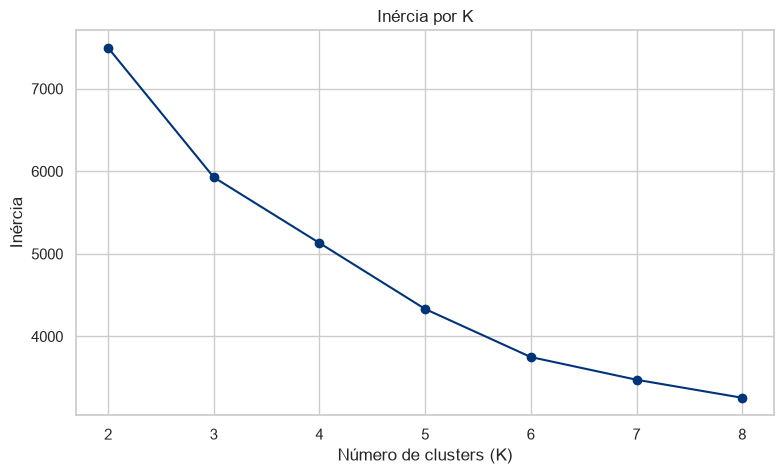

In [6]:
cluster_sample = df.sample(n=min(2_000, len(df)), random_state=SEED)
X_cluster_sample = clustering._derive(cluster_sample)
cluster_rows = []

for k in range(2, 9):
    candidate = clustering.build_pipeline(k=k, seed=SEED)
    labels = candidate.fit_predict(X_cluster_sample)
    scaled = candidate.named_steps["scaler"].transform(X_cluster_sample)
    score = silhouette_score(
        scaled,
        labels,
        sample_size=min(1_500, len(scaled)),
        random_state=SEED,
    )
    cluster_rows.append({
        "k": k,
        "inercia": candidate.named_steps["kmeans"].inertia_,
        "silhouette_amostra": score,
    })

cluster_selection = pd.DataFrame(cluster_rows)
display(cluster_selection.round(3))

fig, axis = plt.subplots(figsize=(9, 5))
axis.plot(cluster_selection["k"], cluster_selection["inercia"], marker="o", color="#003478")
axis.set_xlabel("Número de clusters (K)")
axis.set_ylabel("Inércia")
axis.set_title("Inércia por K")
plt.show()

Silhouette (amostra): 0.285
ARI contra os rótulos sintéticos: 0.469
Cluster → perfil: {2: 'fiel', 1: 'abandono', 3: 'esquecido', 0: 'economico'}


,taxa_aderencia,dias_ultimo,gasto_medio,seguiu_rec
cluster,,,,
0,2.86,136.83,4552.75,0.79
1,0.58,628.35,589.71,0.24
2,6.26,104.22,11403.67,0.90
3,3.85,319.23,4668.69,0.49


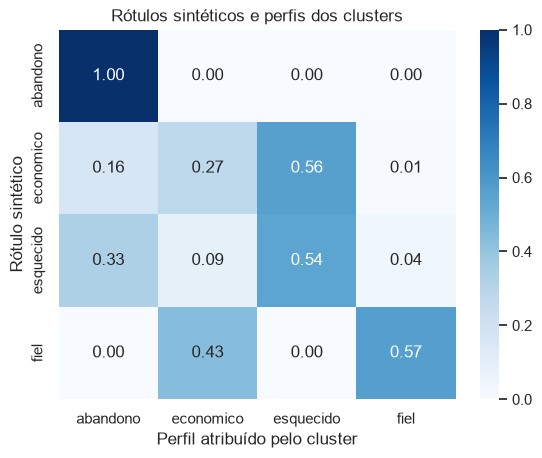

In [7]:
cluster_pipeline = clustering.build_pipeline(k=4, seed=SEED)
X_cluster_all = clustering._derive(df)
cluster_ids = cluster_pipeline.fit_predict(X_cluster_all)

clustered = df.copy()
clustered["cluster"] = cluster_ids
cluster_summary = clustered.groupby("cluster").agg(
    taxa_aderencia=("num_revisoes_realizadas", "mean"),
    dias_ultimo=("dias_desde_ultima_visita", "mean"),
    gasto_medio=("gasto_total_servicos_brl", "mean"),
    seguiu_rec=("seguiu_recomendacoes_pct", "mean"),
)
cluster_map = clustering._map_clusters_to_personas(cluster_summary)
clustered["perfil_descoberto"] = clustered["cluster"].map(cluster_map)

scaled_all = cluster_pipeline.named_steps["scaler"].transform(X_cluster_all)
cluster_silhouette = silhouette_score(
    scaled_all,
    cluster_ids,
    sample_size=min(2_000, len(scaled_all)),
    random_state=SEED,
)
cluster_ari = adjusted_rand_score(clustered[TARGET], clustered["perfil_descoberto"])

print(f"Silhouette (amostra): {cluster_silhouette:.3f}")
print(f"ARI contra os rótulos sintéticos: {cluster_ari:.3f}")
print("Cluster → perfil:", {int(k): v for k, v in cluster_map.items()})
display(cluster_summary.round(2))

cluster_matrix = pd.crosstab(
    clustered[TARGET],
    clustered["perfil_descoberto"],
    normalize="index",
).reindex(index=CLASS_NAMES, columns=CLASS_NAMES, fill_value=0)
sns.heatmap(cluster_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.xlabel("Perfil atribuído pelo cluster")
plt.ylabel("Rótulo sintético")
plt.title("Rótulos sintéticos e perfis dos clusters")
plt.show()

## 4. Classificação supervisionada na Base 2

A avaliação mantém um conjunto de teste estratificado de 20%. Os modelos concorrentes são escolhidos usando apenas validação cruzada no conjunto de treino. A família com melhor F1 macro médio, sem contar o baseline Dummy, segue para busca de hiperparâmetros. O conjunto de teste é usado uma vez para a avaliação final.

O F1 macro pesa as quatro classes igualmente. O F1 ponderado considera a quantidade de exemplos por classe. O conjunto de teste fica reservado até a avaliação do modelo ajustado. Também mostramos precisão e recall por perfil para entender erros que afetariam as ações da concessionária.

In [8]:
X = clean[MODEL_FEATURES].copy()
y = clean[TARGET].map(CLASS_TO_ID).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

print(f"Treino: {len(X_train):,} | Teste reservado: {len(X_test):,}")
print("A mesma distribuição de classes é mantida no treino e no teste.")
display(pd.DataFrame({
    "treino": y_train.value_counts(normalize=True).reindex(range(len(CLASS_NAMES))).values,
    "teste": y_test.value_counts(normalize=True).reindex(range(len(CLASS_NAMES))).values,
}, index=CLASS_NAMES).round(3))

Treino: 8,000 | Teste reservado: 2,000
A mesma distribuição de classes é mantida no treino e no teste.


,treino,teste
abandono,0.276,0.276
economico,0.189,0.188
esquecido,0.212,0.212
fiel,0.323,0.324


In [9]:
def build_preprocessor():
    numeric = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])
    categorical = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    boolean = Pipeline([
        ("cast", FunctionTransformer(
            np.asarray,
            kw_args={"dtype": np.float64},
            feature_names_out="one-to-one",
        )),
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])
    return ColumnTransformer([
        ("numeric", numeric, classifier.NUMERIC),
        ("categorical", categorical, classifier.CATEGORICAL),
        ("boolean", boolean, classifier.BOOLEAN),
    ])

def build_pipeline(estimator):
    return Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", estimator),
    ])

candidates = {
    "Regressão logística": build_pipeline(
        LogisticRegression(
            C=1.0,
            class_weight="balanced",
            max_iter=2_000,
            random_state=SEED,
        )
    ),
    "Random Forest": build_pipeline(
        RandomForestClassifier(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=2,
            random_state=SEED,
        )
    ),
    "XGBoost": build_pipeline(
        XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=len(CLASS_NAMES),
            eval_metric="mlogloss",
            tree_method="hist",
            device=XGBOOST_DEVICE,
            n_jobs=2,
            random_state=SEED,
            verbosity=0,
        )
    ),
}
candidates["Baseline majoritária"] = DummyClassifier(strategy="prior")

print(f"XGBoost usa device={XGBOOST_DEVICE}; K-Means, regressão logística e Random Forest rodam na CPU.")

XGBoost usa device=cuda; K-Means, regressão logística e Random Forest rodam na CPU.


In [10]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "accuracy": "accuracy",
}

comparison_rows = []

for name, candidate in candidates.items():
    started = time.perf_counter()
    cv_result = cross_validate(
        candidate,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    comparison_rows.append({
        "modelo": name,
        "cv_f1_macro_media": cv_result["test_f1_macro"].mean(),
        "cv_f1_macro_dp": cv_result["test_f1_macro"].std(ddof=1),
        "cv_f1_ponderado_media": cv_result["test_f1_weighted"].mean(),
        "cv_acuracia_media": cv_result["test_accuracy"].mean(),
        "tempo_total_s": time.perf_counter() - started,
    })

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("cv_f1_macro_media", ascending=False)
    .reset_index(drop=True)
)
display(comparison.round(3))

non_baseline = comparison.loc[comparison["modelo"] != "Baseline majoritária"]
selected_name = non_baseline.iloc[0]["modelo"]
print(f"Família escolhida pela validação cruzada: {selected_name}")
print("O conjunto de teste permanece reservado até a avaliação do modelo ajustado.")

,modelo,cv_f1_macro_media,cv_f1_macro_dp,cv_f1_ponderado_media,cv_acuracia_media,tempo_total_s
0,XGBoost,0.555,0.006,0.590,0.603,2.637
1,Regressão logística,0.527,0.015,0.563,0.562,0.328
2,Random Forest,0.519,0.009,0.559,0.576,3.756
3,Baseline majoritária,0.122,0.000,0.158,0.323,0.034


Família escolhida pela validação cruzada: XGBoost
O conjunto de teste permanece reservado até a avaliação do modelo ajustado.


### Ajuste de hiperparâmetros

A busca usa apenas os dados de treino e seleciona pela média de F1 macro em três divisões estratificadas. Ela avalia poucas configurações para manter a execução curta. As configurações do teste continuam reservadas até a etapa final.

In [11]:
parameter_grids = {
    "Regressão logística": {
        "model__C": [0.1, 1.0, 10.0],
    },
    "Random Forest": {
        "model__n_estimators": [150, 300],
        "model__max_depth": [None, 12],
        "model__min_samples_leaf": [1, 3],
    },
    "XGBoost": {
        "model__n_estimators": [150, 300],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
    },
}

search = GridSearchCV(
    estimator=clone(candidates[selected_name]),
    param_grid=parameter_grids[selected_name],
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    n_jobs=1,
    refit=True,
    error_score="raise",
)
search.fit(X_train, y_train)

final_model = search.best_estimator_
print(f"Modelo ajustado: {selected_name}")
print("Melhores parâmetros:", search.best_params_)
print(f"F1 macro médio na busca: {search.best_score_:.3f}")
print(f"Combinações avaliadas: {len(search.cv_results_['params'])}")

Modelo ajustado: XGBoost
Melhores parâmetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300}
F1 macro médio na busca: 0.563
Combinações avaliadas: 8


In [12]:
final_prediction = final_model.predict(X_test)
final_metrics = {
    "accuracy": float(accuracy_score(y_test, final_prediction)),
    "f1_macro": float(f1_score(y_test, final_prediction, average="macro")),
    "f1_weighted": float(f1_score(y_test, final_prediction, average="weighted")),
    "precision_macro": float(precision_score(y_test, final_prediction, average="macro", zero_division=0)),
    "recall_macro": float(recall_score(y_test, final_prediction, average="macro", zero_division=0)),
}
report = classification_report(
    y_test,
    final_prediction,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
per_class = pd.DataFrame(report).T.loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]
confusion = confusion_matrix(
    y_test,
    final_prediction,
    labels=list(range(len(CLASS_NAMES))),
)

print(f"F1 macro: {final_metrics['f1_macro']:.3f}")
print(f"F1 ponderado: {final_metrics['f1_weighted']:.3f}")
print(f"Acurácia: {final_metrics['accuracy']:.3f}")
lowest_recall_profile = per_class["recall"].idxmin()
print(
    f"Menor recall: {lowest_recall_profile} "
    f"({per_class.loc[lowest_recall_profile, 'recall']:.3f})"
)
display(per_class.round(3))

F1 macro: 0.570
F1 ponderado: 0.602
Acurácia: 0.620
Menor recall: esquecido (0.281)


,precision,recall,f1-score,support
abandono,0.573,0.714,0.636,553.0
economico,0.474,0.462,0.468,377.0
esquecido,0.559,0.281,0.374,423.0
fiel,0.755,0.853,0.801,647.0


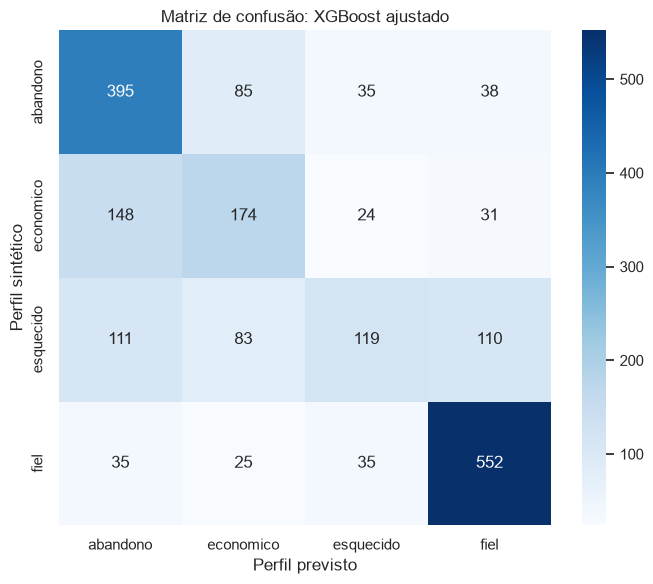

Cada linha é o perfil sintético real; cada coluna é a previsão.
Observe em especial quantos clientes de abandono foram previstos como fiéis ou econômicos.


In [13]:
fig, axis = plt.subplots(figsize=(7, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axis,
)
axis.set_xlabel("Perfil previsto")
axis.set_ylabel("Perfil sintético")
axis.set_title(f"Matriz de confusão: {selected_name} ajustado")
plt.tight_layout()
plt.show()

print("Cada linha é o perfil sintético real; cada coluna é a previsão.")
print("Observe em especial quantos clientes de abandono foram previstos como fiéis ou econômicos.")

,importância
numeric__renda_mensal_brl,0.138776
numeric__score_credito,0.108298
numeric__idade,0.090676
categorical__financiamento_a_vista,0.037834
categorical__financiamento_financiado,0.037197
numeric__parcelas,0.031150
categorical__regiao_centro_oeste,0.019433
categorical__regiao_sudeste,0.019366
categorical__canal_aquisicao_indicacao,0.019064
categorical__modelo_comprado_Ka,0.017750


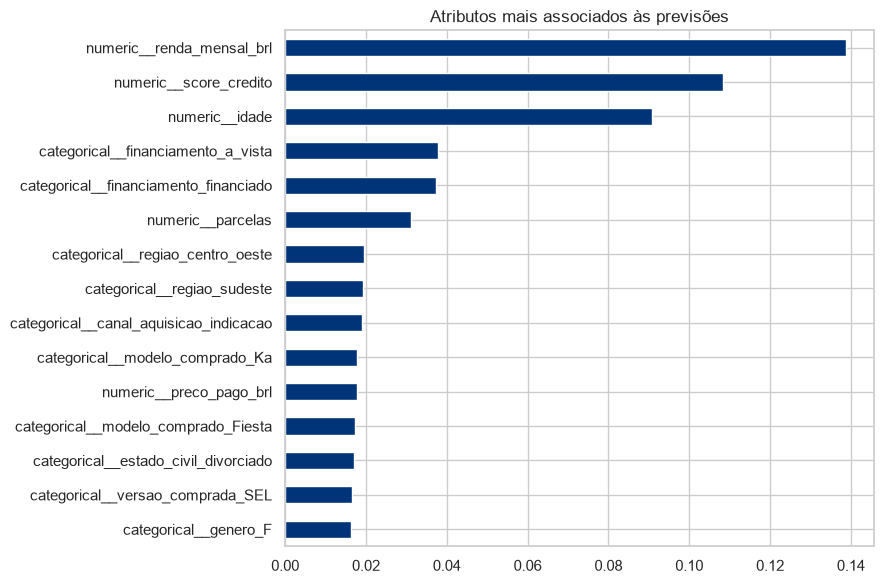

In [14]:
fitted_estimator = final_model.named_steps["model"]
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()

if hasattr(fitted_estimator, "feature_importances_"):
    importance = pd.Series(
        fitted_estimator.feature_importances_,
        index=feature_names,
    ).sort_values(ascending=False).head(15)
elif hasattr(fitted_estimator, "coef_"):
    importance = pd.Series(
        np.abs(fitted_estimator.coef_).mean(axis=0),
        index=feature_names,
    ).sort_values(ascending=False).head(15)
else:
    importance = pd.Series(dtype=float)

if not importance.empty:
    display(importance.rename("importância").to_frame())
    importance.sort_values().plot.barh(figsize=(9, 6), color="#003478")
    plt.title("Atributos mais associados às previsões")
    plt.tight_layout()
    plt.show()

## 5. Leitura do resultado e uso na FaroAI

O critério de escolha é o F1 macro médio na validação cruzada do treino. A busca ajusta apenas a família escolhida. A tabela do conjunto de teste é uma avaliação final; não usamos esses números para escolher de novo o algoritmo.

Na aplicação, o perfil pode orientar a fila de leads e as ações já definidas por perfil. O Node API chama o serviço FastAPI em /predict, que carrega um artefato joblib e devolve probabilidades. O pipeline abaixo usa as mesmas 14 entradas de compra que src.classifier espera. O notebook salva um artefato candidato versionado, mas não altera o modelo em execução.

Antes de trocar o modelo sintético por um modelo de produção, é preciso treinar e avaliar com dados Ford aprovados e desidentificados. A base real deve ser dividida por data ou concessionária, e os agregados por perfil devem usar somente clientes anteriores ao caso previsto. O ETL real atual calcula taxas de perfil de concessionária e modelo sobre todos os rótulos antes da divisão. Não usamos essas taxas neste experimento.

In [15]:
sample_input = X_test.iloc[0].to_dict()
print("Exemplo de entrada do conjunto de teste:")
display(pd.Series(sample_input).to_frame("valor"))
print("Perfil sintético:", CLASS_NAMES[int(y_test.iloc[0])])

model_version = f"sprint3-{selected_name.lower().replace(' ', '-')}-v1"
artifact_path = ML_DIR / "models" / "classifier_sprint3_candidate.joblib"
artifact_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(
    {
        "pipeline": final_model,
        "metrics": final_metrics,
        "labels": CLASS_NAMES,
        "version": model_version,
    },
    artifact_path,
)

loaded_pipeline, _, loaded_version = classifier.load(str(artifact_path))
sample_prediction = classifier.predict(loaded_pipeline, sample_input)
print("Resposta pelo loader e predictor usados pelo serviço:")
print("Versão carregada:", loaded_version)
display(sample_prediction)
print(f"Candidato salvo em {artifact_path}")
print("O serviço continua carregando classifier_base2.joblib. Este arquivo não promove o modelo.")


Exemplo de entrada do conjunto de teste:


,valor
idade,42
renda_mensal_brl,6967
score_credito,644
preco_pago_brl,113353
parcelas,60
genero,F
regiao,sudeste
estado_civil,divorciado
modelo_comprado,Ranger
versao_comprada,XL


Perfil sintético: economico
Resposta pelo loader e predictor usados pelo serviço:
Versão carregada: sprint3-xgboost-v1


{'perfil_predito': 'abandono',
 'probabilidades': {'abandono': 0.40060651302337646,
  'economico': 0.3400331437587738,
  'esquecido': 0.20040775835514069,
  'fiel': 0.058952558785676956},
 'risco_evasao': 0.5208511680364609,
 'confianca': 0.40060651302337646}

Candidato salvo em /home/tept/Projects/ford-fiap-challenge/services/ml/models/classifier_sprint3_candidate.joblib
O serviço continua carregando classifier_base2.joblib. Este arquivo não promove o modelo.


## 6. Relatório e próximos passos

A próxima célula grava um resumo com as contagens da auditoria, comparação por validação cruzada, parâmetros escolhidos e métricas de teste medidas nesta execução. Em Colab, o notebook baixa o arquivo Markdown para que ele possa ser enviado junto com o notebook.

In [16]:
def markdown_table(frame: pd.DataFrame) -> str:
    values = frame.copy()
    headers = list(values.columns)
    lines = [
        "| " + " | ".join(str(value) for value in headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    for row in values.itertuples(index=False, name=None):
        rendered = []
        for value in row:
            if isinstance(value, (float, np.floating)):
                rendered.append(f"{value:.3f}")
            else:
                rendered.append(str(value))
        lines.append("| " + " | ".join(rendered) + " |")
    return "\n".join(lines)

comparison_for_report = comparison[
    ["modelo", "cv_f1_macro_media", "cv_f1_macro_dp", "cv_f1_ponderado_media",
     "cv_acuracia_media"]
].copy()

per_class_for_report = per_class.reset_index(names="perfil").rename(columns={
    "f1-score": "f1",
})
confusion_for_report = pd.DataFrame(
    confusion,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).rename_axis("perfil_sintetico").reset_index()
params_text = json.dumps(search.best_params_, ensure_ascii=False, sort_keys=True)

report_text = f"""# Sprint 3: Inteligência Artificial e Machine Learning

## Problema

A FaroAI classifica clientes em quatro perfis de retenção para orientar a priorização de leads e as ações de concessionária. Esta execução usa uma base sintética gerada por services/ml/src/synthetic.py, com 10.000 registros e semente {SEED}. O rótulo é criado pelo próprio gerador. Estas métricas avaliam a recuperação dos rótulos sintéticos e não representam desempenho em clientes Ford reais.

## Dados e preparação

- Base 1: {len(base1):,} registros com sinais pós-compra, usada para segmentação exploratória.
- Base 2: {len(clean):,} registros utilizáveis após limpeza, com {len(MODEL_FEATURES)} entradas de compra no classificador.
- Divisão estratificada: {len(X_train):,} treino e {len(X_test):,} teste.
- Duplicatas removidas: {quality["duplicatas_removidas"]}.
- Rótulos inválidos removidos: {quality["rotulos_invalidos_removidos"]}.
- Valores fora dos limites convertidos em ausentes: {sum(quality["valores_fora_limite_convertidos_em_ausentes"].values())}.
- Sinais de outlier pelo IQR, revisados e mantidos quando plausíveis: {quality["outliers_IQR_sinalizados"]}.
- Valores ausentes são imputados dentro do pipeline. Dados pós-compra não entram no classificador.

## Comparação de modelos

A seleção usa F1 macro médio em validação cruzada estratificada de três partes no treino. O conjunto de teste não escolhe o algoritmo.

{markdown_table(comparison_for_report)}

## Modelo final

A família escolhida foi **{selected_name}**, ajustada por busca em grade no treino. Parâmetros: {params_text}.

F1 macro no teste: **{final_metrics["f1_macro"]:.3f}**.  
F1 ponderado no teste: **{final_metrics["f1_weighted"]:.3f}**.  
Acurácia no teste: **{final_metrics["accuracy"]:.3f}**.

A menor revocação foi **{per_class.loc[lowest_recall_profile, "recall"]:.3f}** para o perfil **{lowest_recall_profile}**; essa classe merece atenção na revisão de erros.

{markdown_table(per_class_for_report.round(3))}

### Matriz de confusão

Cada linha é o perfil sintético; cada coluna é o perfil previsto.

{markdown_table(confusion_for_report)}

## Uso e limites

O perfil previsto pode priorizar leads e selecionar ações já associadas aos perfis no FaroAI. O artefato classifier_sprint3_candidate.joblib segue o formato carregado pelo predictor Python, mas esta execução não substitui o arquivo usado pelo serviço. A avaliação foi feita com rótulos sintéticos e não aprova uso em produção.

Para avançar, treinar com dados Ford aprovados e desidentificados, corrigir os agregados de dealer/modelo para usar apenas registros anteriores, medir desempenho em uma separação temporal ou por concessionária e revisar erros por perfil antes de integrar o modelo à API.

## Computação

As células de análise e treino levaram {time.perf_counter() - EXPERIMENT_STARTED:.1f} segundos nesta sessão. O XGBoost usou {GPU_NAME or 'CPU'} com device={XGBOOST_DEVICE}. K-Means, regressão logística e Random Forest rodam na CPU. Se não houver GPU ou suporte CUDA no XGBoost, o notebook usa CPU. O tempo varia conforme o processador e o runtime.
"""

report_path = REPO_ROOT / "docs" / "deliverables" / "Relatorio_Sprint3_IA_ML_Challenge2.md"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(report_text, encoding="utf-8")
print(f"Relatório salvo em {report_path}")
display(comparison_for_report.round(3))
display(per_class_for_report.round(3))

if IN_COLAB:
    from google.colab import files
    files.download(str(report_path))

Relatório salvo em /home/tept/Projects/ford-fiap-challenge/docs/deliverables/Relatorio_Sprint3_IA_ML_Challenge2.md


,modelo,cv_f1_macro_media,cv_f1_macro_dp,cv_f1_ponderado_media,cv_acuracia_media
0,XGBoost,0.555,0.006,0.590,0.603
1,Regressão logística,0.527,0.015,0.563,0.562
2,Random Forest,0.519,0.009,0.559,0.576
3,Baseline majoritária,0.122,0.000,0.158,0.323


,perfil,precision,recall,f1,support
0,abandono,0.573,0.714,0.636,553.0
1,economico,0.474,0.462,0.468,377.0
2,esquecido,0.559,0.281,0.374,423.0
3,fiel,0.755,0.853,0.801,647.0
